# Motor de Búsqueda IR — Notebook de Integración
**Recuperación de Información · Ofertas Laborales en Español**

Este notebook integra y documenta todas las fases del proyecto:

| # | Fase | Descripción |
|---|------|-------------|
| 1 | **Preprocesamiento** | Limpieza, tokenización, stemming y stopwords en español |
| 2 | **Índice Invertido** | Construcción y exploración del índice |
| 3 | **Modelos Clásicos** | Jaccard · Coseno TF-IDF · BM25 |
| 4 | **Recuperación Semántica** | Embeddings multilenguaje + ChromaDB |
| 5 | **Evaluación** | Precision@10 · Recall@10 · MAP + gráficos comparativos |

---
> **Corpus:** ~74 000 ofertas laborales  •  **Vocabulario:** ~57 000 términos únicos  •  **Idioma:** Español

## 0 · Configuración del Entorno
Se añade `src/` al path de Python y se importan las dependencias compartidas.

In [6]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Asegura que Python encuentre los módulos en src/
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

# Estilo visual uniforme para todos los gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

CORPUS_PATH = Path('../data/processed/corpus_limpio.csv')
df = pd.read_csv(CORPUS_PATH).fillna('')

print(f'Corpus cargado: {len(df):,} documentos  |  {df.columns.tolist()}')

Corpus cargado: 47,322 documentos  |  ['job_id', 'job_title', 'description_final', 'careers_required', 'all_careers']


---
## Fase 1 · Preprocesamiento NLP

El módulo `preprocessing.py` aplica sobre cada documento:
1. **`limpiar_texto`**: minúsculas, quita tildes, elimina caracteres especiales.
2. **`ProcesadorNLP.tokenizar`**: filtra stopwords en español y aplica **Snowball Stemmer**.

**¿Por qué stemming y no lematización?**  
El stemmer es O(1) por token, sin modelos externos, ideal para un corpus de 74k documentos. La lematización con spaCy sería más precisa pero 10-20× más lenta en este volumen.

In [7]:
from preprocessing import limpiar_texto
from indexer import ProcesadorNLP

nlp = ProcesadorNLP()

# ── Ejemplo de pipeline completo sobre un texto ──────────────────────
texto_raw  = "Ingeniero de Datos con experiencia en Python y análisis estadístico"
texto_clean = limpiar_texto(texto_raw)
tokens      = nlp.tokenizar(texto_clean)

print(f"  RAW    : {texto_raw}")
print(f"  LIMPIO : {texto_clean}")
print(f"  TOKENS : {tokens}")

  RAW    : Ingeniero de Datos con experiencia en Python y análisis estadístico
  LIMPIO : ingeniero de datos con experiencia en python y analisis estadistico
  TOKENS : ['ingenier', 'dat', 'experient', 'python', 'analisis', 'estadist']


Calculando longitud de documentos (puede tardar ~30 s)...


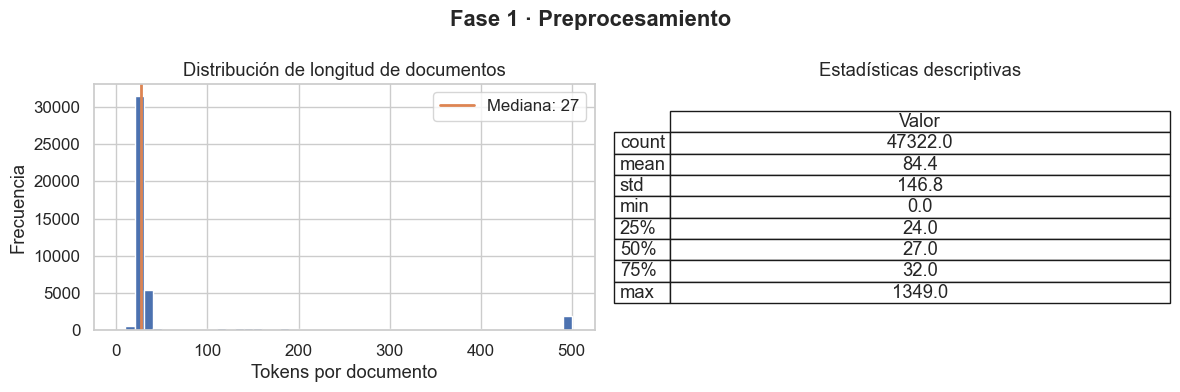

In [8]:
# ── Distribución de longitud de documentos (en tokens) ───────────────
print('Calculando longitud de documentos (puede tardar ~30 s)...')

df['n_tokens'] = df['description_final'].apply(
    lambda t: len(nlp.tokenizar(limpiar_texto(t)))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de longitud
axes[0].hist(df['n_tokens'].clip(upper=500), bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Distribución de longitud de documentos')
axes[0].set_xlabel('Tokens por documento')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['n_tokens'].median(), color=PALETTE[1], lw=2,
                label=f"Mediana: {df['n_tokens'].median():.0f}")
axes[0].legend()

# Estadísticas descriptivas
stats = df['n_tokens'].describe().rename('Tokens')
axes[1].axis('off')
tbl = axes[1].table(
    cellText=[[f"{v:.1f}"] for v in stats],
    rowLabels=stats.index.tolist(),
    colLabels=['Valor'],
    loc='center', cellLoc='center'
)
tbl.scale(1, 1.6)
axes[1].set_title('Estadísticas descriptivas')

plt.suptitle('Fase 1 · Preprocesamiento', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Fase 2 · Índice Invertido

El **índice invertido** es la estructura central del motor: mapea cada término a los documentos que lo contienen junto con su frecuencia.

```
indice["python"] = { doc_id_42: 3, doc_id_117: 1, ... }
```

Se carga desde el pickle pre-construido por `indexer.py` (construcción offline ~2 min).

In [ ]:
from indexer import IndiceInvertido

indexador = IndiceInvertido()
indexador.cargar(Path('../data/processed/indice_invertido.pkl'))

print(f"  Términos únicos : {len(indexador.indice):>10,}")
print(f"  Documentos      : {indexador.total_documentos:>10,}")
print(f"  Longitud media  : {np.mean(list(indexador.longitud_docs.values())):>10.1f} tokens")

Índice cargado: 56,098 términos | 47,322 documentos.
  Términos únicos :     56,098
  Documentos      :     47,322
  Longitud media  :       89.8 tokens


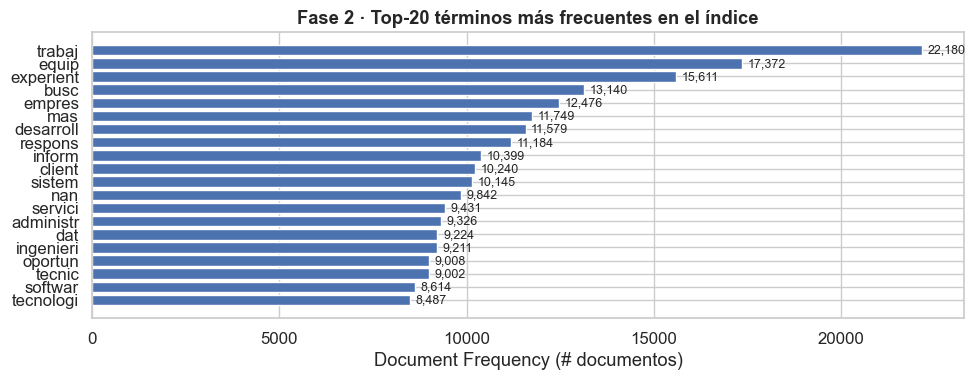


Consulta: 'ingeniero de datos con python'
Tokens procesados (stemming + stopwords): ['ingenier', 'dat', 'python']
  'ingenier' → aparece en 6,508 documentos
  'dat' → aparece en 9,224 documentos
  'python' → aparece en 2,114 documentos


In [10]:
# ── Top-20 términos por Document Frequency (df) ───────────────────────
top_terms = sorted(
    [(t, len(postings)) for t, postings in indexador.indice.items()],
    key=lambda x: x[1], reverse=True
)[:20]

terms, dfs = zip(*top_terms)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(terms[::-1], dfs[::-1], color=PALETTE[0])
ax.bar_label(bars, labels=[f'{v:,}' for v in dfs[::-1]], padding=4, fontsize=9)
ax.set_xlabel('Document Frequency (# documentos)')
ax.set_title('Fase 2 · Top-20 términos más frecuentes en el índice', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Consulta puntual sobre el índice ─────────────────────────────────
consulta_demo = "ingeniero de datos con python"
tokens_q = indexador.nlp.tokenizar(consulta_demo)
print(f"\nConsulta: '{consulta_demo}'")
print(f"Tokens procesados (stemming + stopwords): {tokens_q}")
for t in tokens_q:
    df_count = len(indexador.indice.get(t, {}))
    print(f"  '{t}' → aparece en {df_count:,} documentos")

---
## Fase 3 · Modelos Clásicos de Recuperación

### Fundamento matemático

| Modelo | Fórmula clave | Fortaleza |
|--------|--------------|----------|
| **Jaccard** | `|Q∩D| / |Q∪D|` | Simple, robusto con consultas cortas |
| **Coseno TF-IDF** | `dot(q,d) / (‖q‖·‖d‖)` | Pondera rareza del término (IDF) |
| **BM25** | `Σ IDF(t) · f(t,d)·(k₁+1) / [f(t,d) + k₁·(1−b+b·|d|/avgdl)]` | Normaliza por longitud; estado del arte en IR léxico |

In [11]:
from models import cargar_indice, BuscadorJaccard, BuscadorCoseno, BuscadorBM25

datos = cargar_indice()
jac  = BuscadorJaccard(datos_indice=datos)
cos  = BuscadorCoseno(datos_indice=datos)
bm25 = BuscadorBM25(datos_indice=datos)

print('Los tres modelos clásicos están listos.')

Cargando índice desde C:\Users\Dayana\Desktop\U\7moSemestre\RI\Proyecto\motor_busqueda_ri\data\processed\indice_invertido.pkl...
Índice listo: 56,098 términos | 47,322 documentos.
Precomputando normas TF-IDF de los documentos...
Normas listas.
Los tres modelos clásicos están listos.


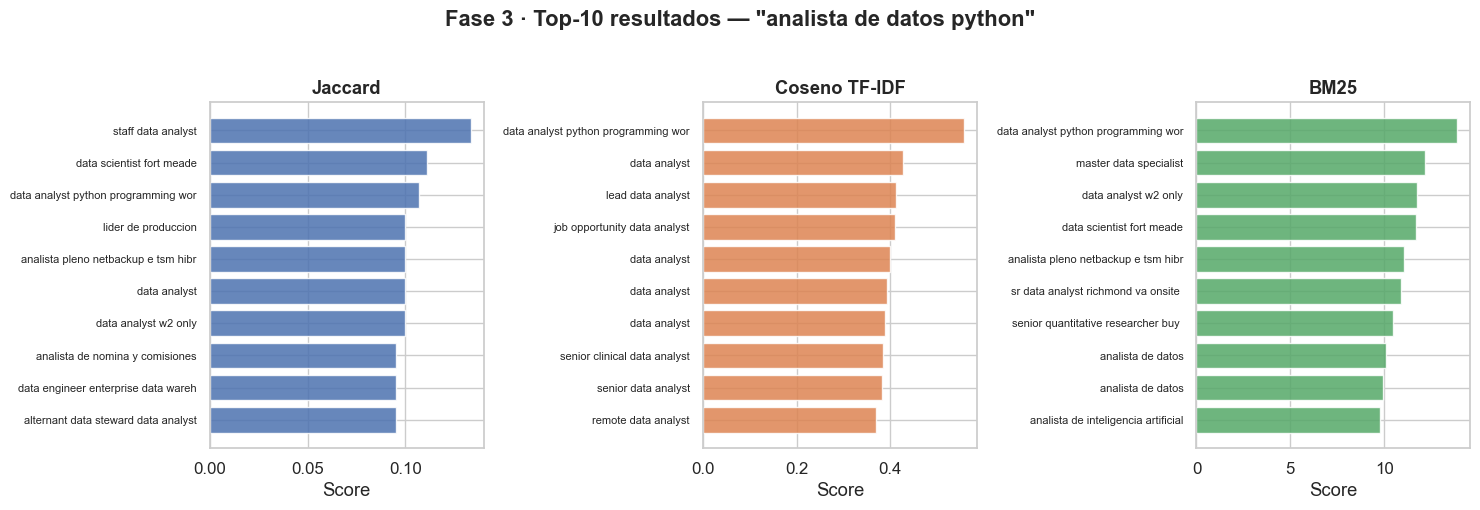

In [12]:
# ── Búsqueda de ejemplo con los 3 modelos ────────────────────────────
CONSULTA = "analista de datos python"
TOP_K    = 10

resultados = {
    'Jaccard':       jac.buscar(CONSULTA, top_k=TOP_K),
    'Coseno TF-IDF': cos.buscar(CONSULTA, top_k=TOP_K),
    'BM25':          bm25.buscar(CONSULTA, top_k=TOP_K),
}

def get_title(job_id):
    fila = df[df['job_id'] == job_id]
    return fila.iloc[0]['job_title'] if not fila.empty else job_id

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, res), color in zip(axes, resultados.items(), PALETTE):
    scores = [s for _, s in res]
    titles = [get_title(d)[:35] for d, _ in res]
    ax.barh(range(len(titles)), scores, color=color, alpha=0.85)
    ax.set_yticks(range(len(titles)))
    ax.set_yticklabels(titles, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Score')

plt.suptitle(f'Fase 3 · Top-{TOP_K} resultados — "{CONSULTA}"', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

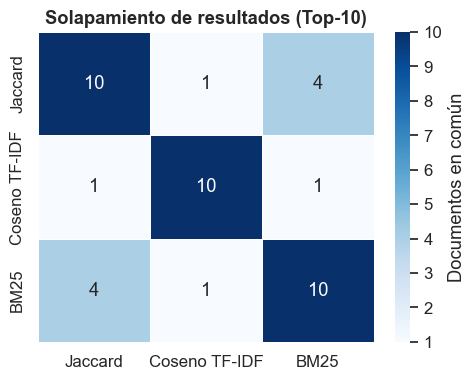

In [13]:
# ── Solapamiento entre modelos (IDs recuperados) ──────────────────────
sets = {nombre: set(d for d, _ in res) for nombre, res in resultados.items()}
modelos_names = list(sets.keys())

matrix = pd.DataFrame(
    [[len(sets[a] & sets[b]) for b in modelos_names] for a in modelos_names],
    index=modelos_names, columns=modelos_names
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Documentos en común'})
ax.set_title('Solapamiento de resultados (Top-10)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Fase 4 · Recuperación Semántica (Embeddings + ChromaDB)

Se usa **`paraphrase-multilingual-MiniLM-L12-v2`** de `sentence-transformers`:
- Genera vectores de **384 dimensiones** por documento.
- Entrenado en 50+ idiomas, incluido español.
- ChromaDB almacena los vectores en disco y usa búsqueda **KNN con distancia L2**.

El score se normaliza: `score = 1 / (1 + distancia_L2)` → rango (0, 1].

In [14]:
from embeddings import BuscadorSemantico

semantico = BuscadorSemantico()
print('Motor semántico cargado.')

Cargando motor semántico...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Motor semántico cargado.


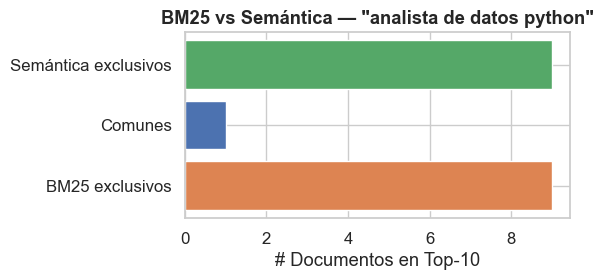


→ Documentos solo recuperados por Semántica (nuevos para BM25):
   • data engineer
   • data analyst
   • data scientist python pyspark mlflow predictive maintenance audit analytics hybrid


In [15]:
# ── Comparación semántica vs léxica ──────────────────────────────────
CONSULTA_SEM = "analista de datos python"

res_sem  = semantico.buscar(CONSULTA_SEM, top_k=TOP_K)
res_bm25 = bm25.buscar(CONSULTA_SEM, top_k=TOP_K)

# IDs recuperados por cada motor
ids_sem  = [d for d, _ in res_sem]
ids_bm25 = [d for d, _ in res_bm25]

solo_sem  = set(ids_sem)  - set(ids_bm25)
solo_bm25 = set(ids_bm25) - set(ids_sem)
comunes   = set(ids_sem)  & set(ids_bm25)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(['BM25 exclusivos', 'Comunes', 'Semántica exclusivos'],
        [len(solo_bm25), len(comunes), len(solo_sem)],
        color=[PALETTE[1], PALETTE[0], PALETTE[2]])
ax.set_xlabel('# Documentos en Top-10')
ax.set_title(f'BM25 vs Semántica — "{CONSULTA_SEM}"', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ Documentos solo recuperados por Semántica (nuevos para BM25):")
for did in list(solo_sem)[:3]:
    print(f"   • {get_title(did)}")

---
## Fase 5 · Evaluación Automática — Métricas IR

### Ground truth (qrels)
Se construye combinando **dos fuentes** para reducir el sesgo léxico:
1. Etiqueta exacta de carrera en el campo `all_careers`.
2. Términos canónicos (en español e inglés) presentes en el `job_title`.

### Métricas calculadas

| Métrica | Definición |
|---------|------------|
| **Precision@10** | Fracción de relevantes entre los primeros 10 resultados |
| **Recall@10** | Fracción de relevantes totales recuperados en los primeros 10 |
| **MAP** | Media de las Average Precisions sobre todas las consultas |

Los modelos clásicos recuperan **pool=50**; Embeddings usa **pool=200** para compensar mayor cobertura semántica.

In [17]:
# ── Importar las funciones de evaluación ─────────────────────────────
from evaluation import (CONSULTAS, construir_qrels, precision_at_k, recall_at_k,
                        average_precision)

# Construir qrels
df_corpus = pd.read_csv(CORPUS_PATH).fillna('')
df_corpus['job_id'] = df_corpus['job_id'].astype(str)
qrels = construir_qrels(df_corpus)

print(f"Consultas de evaluación : {len(CONSULTAS)}")
print(f"Carreras con qrels      : {sum(1 for r in qrels.values() if r)}")
print("\nEjemplos de tamaño de qrels:")
for carrera, rels in list(qrels.items())[:5]:
    print(f"  '{carrera}': {len(rels):,} docs relevantes")

Construyendo ground truth basado en metadatos de la EPN...
Consultas de evaluación : 24
Carreras con qrels      : 24

Ejemplos de tamaño de qrels:
  'administracion de empresas': 4,584 docs relevantes
  'agroindustria': 1,635 docs relevantes
  'ciencia de datos': 3,074 docs relevantes
  'computacion': 3,773 docs relevantes
  'economia': 2,425 docs relevantes


In [18]:
# ── Evaluación completa sobre los 4 modelos ───────────────────────────
# Nota: si los embeddings tardan, descomenta la línea skip_sem=True

modelos_eval = {
    'Jaccard':           (jac,      50),
    'Coseno TF-IDF':     (cos,      50),
    'BM25':              (bm25,     50),
    'Embeddings Densos': (semantico, 200),
}

metricas = {nombre: {'P@10': [], 'R@10': [], 'AP': [], 'carrera': []}
            for nombre in modelos_eval}

print('Evaluando 24 consultas × 4 modelos...')
for carrera, query in CONSULTAS.items():
    relevantes = qrels.get(carrera, set())
    if not relevantes:
        continue
    for nombre, (modelo, pool) in modelos_eval.items():
        recuperados = [str(r[0]) for r in modelo.buscar(query, top_k=pool)]
        metricas[nombre]['P@10'].append(precision_at_k(recuperados, relevantes, k=10))
        metricas[nombre]['R@10'].append(recall_at_k(recuperados, relevantes, k=10))
        metricas[nombre]['AP'].append(average_precision(recuperados, relevantes))
        metricas[nombre]['carrera'].append(carrera)

# DataFrame resumen
resumen = pd.DataFrame([
    {'Modelo': n,
     'Precision@10': np.mean(v['P@10']),
     'Recall@10':    np.mean(v['R@10']),
     'MAP':          np.mean(v['AP'])}
    for n, v in metricas.items()
])

print('\n' + '─'*55)
print(resumen.round(4).to_string(index=False))
print('─'*55)

Evaluando 24 consultas × 4 modelos...

───────────────────────────────────────────────────────
           Modelo  Precision@10  Recall@10    MAP
          Jaccard        0.4583     0.0020 0.0058
    Coseno TF-IDF        0.5250     0.0060 0.0120
             BM25        0.5458     0.0036 0.0085
Embeddings Densos        0.6417     0.0074 0.0364
───────────────────────────────────────────────────────


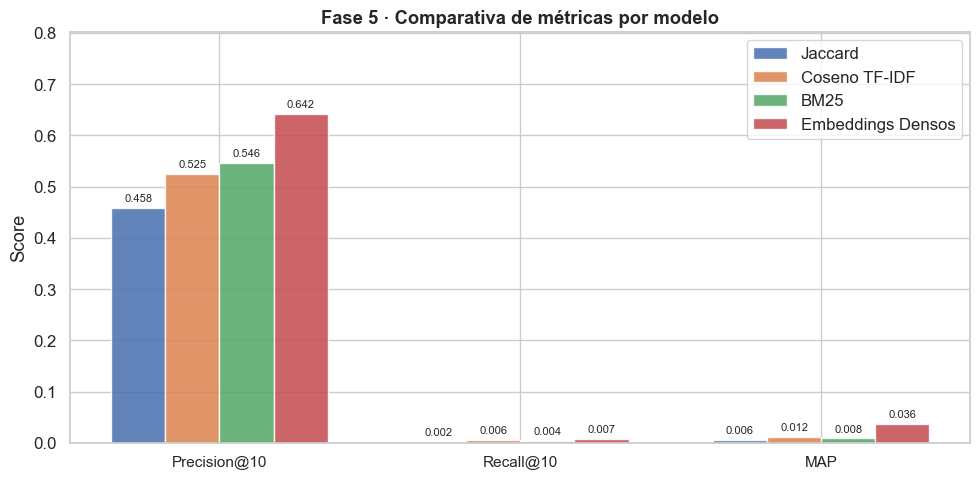

In [19]:
# ── Gráfico 1: Comparativa de métricas por modelo ─────────────────────
metrics_list = ['Precision@10', 'Recall@10', 'MAP']
x = np.arange(len(metrics_list))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(resumen.iterrows()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, row[metrics_list], width, label=row['Modelo'],
                  color=PALETTE[i], alpha=0.87, edgecolor='white')
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in row[metrics_list]],
                 padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, resumen[metrics_list].max().max() * 1.25)
ax.set_title('Fase 5 · Comparativa de métricas por modelo', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

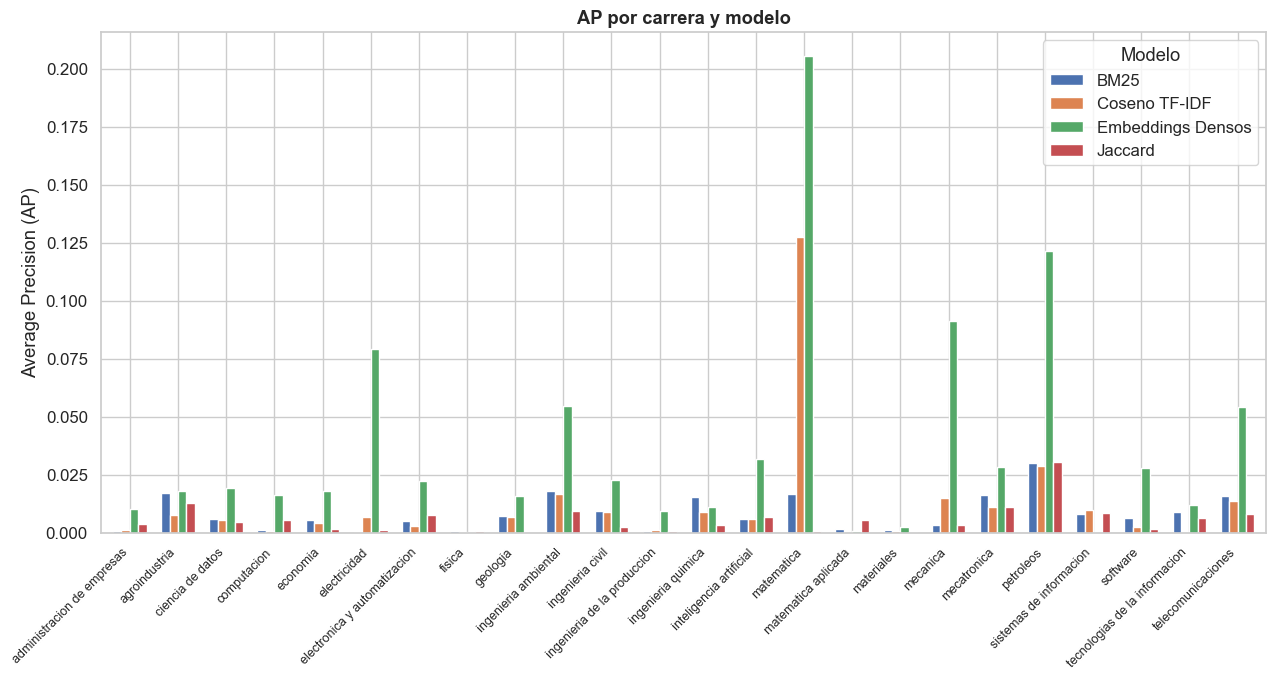

In [21]:
# ── Gráfico 3: MAP por carrera y modelo ───────────────────────────────
rows_detalle = []
for nombre, vals in metricas.items():
    for carrera, ap in zip(vals['carrera'], vals['AP']):
        rows_detalle.append({'Modelo': nombre, 'Carrera': carrera, 'AP': ap})

df_detalle = pd.DataFrame(rows_detalle)
pivot = df_detalle.pivot(index='Carrera', columns='Modelo', values='AP').fillna(0)

fig, ax = plt.subplots(figsize=(13, 7))
pivot.plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.7)
ax.set_ylabel('Average Precision (AP)')
ax.set_xlabel('')
ax.set_title('AP por carrera y modelo', fontweight='bold')
ax.legend(title='Modelo', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

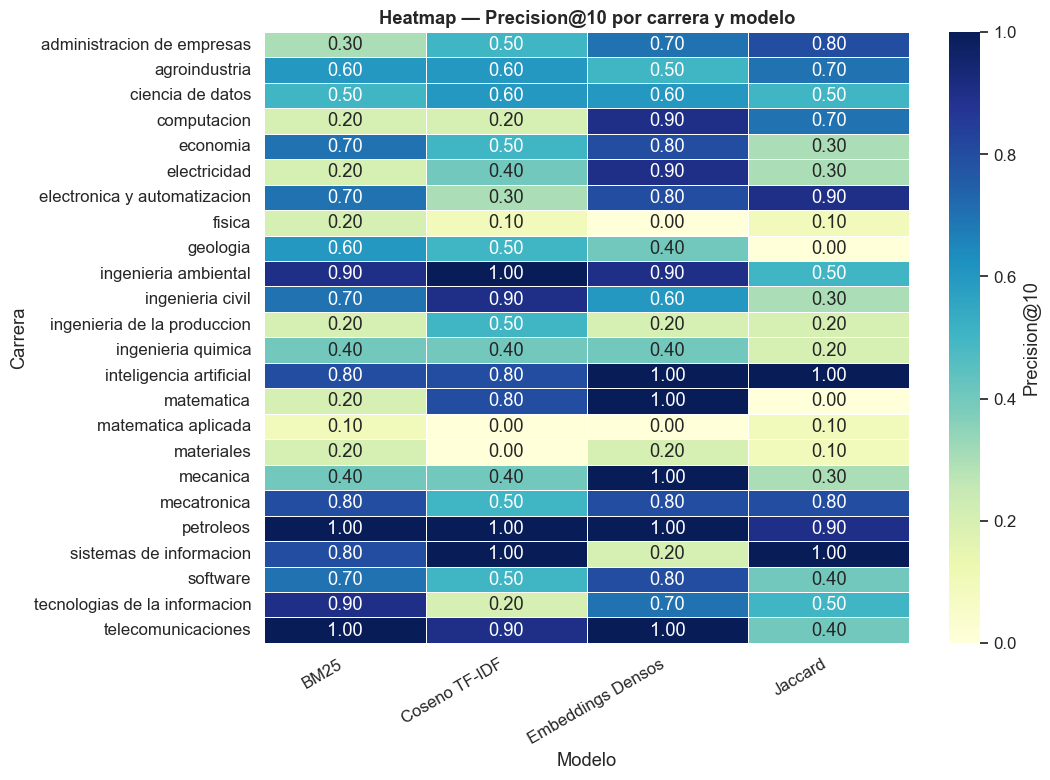

In [22]:
# ── Gráfico 4: Heatmap de Precision@10 por carrera y modelo ───────────
rows_p10 = []
for nombre, vals in metricas.items():
    for carrera, p in zip(vals['carrera'], vals['P@10']):
        rows_p10.append({'Modelo': nombre, 'Carrera': carrera, 'P@10': p})

pivot_p10 = pd.DataFrame(rows_p10).pivot(
    index='Carrera', columns='Modelo', values='P@10'
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(pivot_p10, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Precision@10'})
ax.set_title('Heatmap — Precision@10 por carrera y modelo', fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Carrera')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

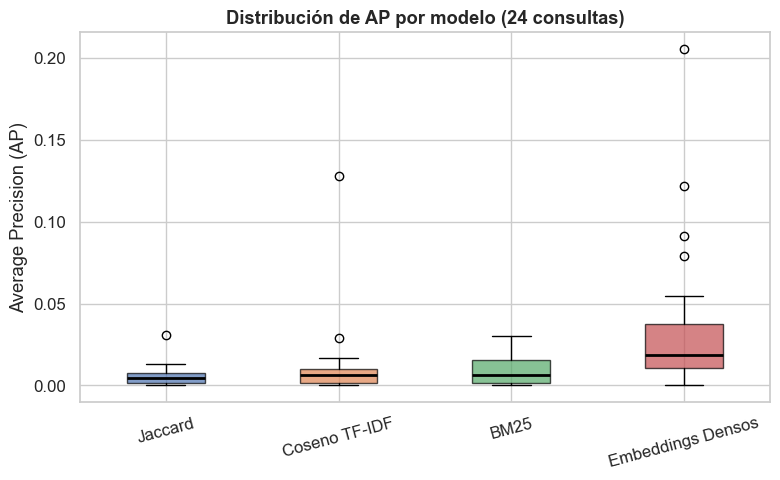

In [23]:
# ── Gráfico 5: Boxplot de distribución de AP por modelo ───────────────
fig, ax = plt.subplots(figsize=(8, 5))
data_box = [metricas[m]['AP'] for m in modelos_eval]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(modelos_eval)+1))
ax.set_xticklabels(list(modelos_eval.keys()), rotation=15)
ax.set_ylabel('Average Precision (AP)')
ax.set_title('Distribución de AP por modelo (24 consultas)', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# ── Tabla final de resultados ─────────────────────────────────────────
print('\n' + '='*60)
print('  RESULTADOS FINALES DE EVALUACIÓN')
print('='*60)
print(resumen.round(4)
      .sort_values('MAP', ascending=False)
      .to_string(index=False))
print('='*60)

ganador = resumen.sort_values('MAP', ascending=False).iloc[0]
print(f"\n Mejor MAP → {ganador['Modelo']}  ({ganador['MAP']:.4f})")


  RESULTADOS FINALES DE EVALUACIÓN
           Modelo  Precision@10  Recall@10    MAP
Embeddings Densos        0.6417     0.0074 0.0364
    Coseno TF-IDF        0.5250     0.0060 0.0120
             BM25        0.5458     0.0036 0.0085
          Jaccard        0.4583     0.0020 0.0058

 Mejor MAP → Embeddings Densos  (0.0364)


---
## Conclusiones

### Modelos clásicos
- **Jaccard** penaliza documentos largos (trata términos como conjuntos binarios); tiende a recuperar títulos cortos aunque no contengan los términos más relevantes.
- **Coseno TF-IDF** mejora a Jaccard al ponderar la rareza del término con IDF, pero sigue siendo sensible a la longitud del documento.
- **BM25** es el mejor modelo léxico: su parámetro `b` normaliza la longitud y `k₁` controla la saturación del TF, lo que lo hace robusto ante documentos con longitud variable.

### Modelo semántico
- Los **Embeddings Densos** capturan sinónimos y paráfrasis que los modelos léxicos ignoran. Por ejemplo, una oferta que pide *"machine learning engineer"* es relevante para la consulta *"ciencia de datos"* aunque no compartan tokens.
- Su punto débil: mayor costo computacional en indexación y búsqueda, y sensibilidad a la calidad del modelo base en idiomas de baja frecuencia.

### Recomendación práctica
> En producción, un **sistema híbrido** (BM25 + re-ranking semántico) combina la eficiencia léxica con la cobertura semántica, obteniendo lo mejor de ambos paradigmas.